In [3]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END

## Reducers
from typing import Annotated
from langgraph.graph.message import add_messages

In [4]:
class State(TypedDict):
    messages: Annotated[list,add_messages]

In [5]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

In [7]:
from langchain_openai import ChatOpenAI
llm=ChatOpenAI(model="gpt-4o")
llm.invoke("HI")

AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 8, 'total_tokens': 17, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_cbf1785567', 'id': 'chatcmpl-CWnukODPhqhJM5hnRI0jxONq4abFd', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--aa830d89-b2b2-4c9b-91c1-eaa4957dc10d-0', usage_metadata={'input_tokens': 8, 'output_tokens': 9, 'total_tokens': 17, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [11]:
from langchain_groq import ChatGroq
llm_groq=ChatGroq(model="llama-3.1-8b-instant")
llm_groq.invoke("HI")

AIMessage(content="It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 36, 'total_tokens': 59, 'completion_time': 0.02228806, 'prompt_time': 0.001858285, 'queue_time': 0.047505624, 'total_time': 0.024146345}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_ab04adca7d', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--b4d94187-2666-43d6-b17b-56b29132e272-0', usage_metadata={'input_tokens': 36, 'output_tokens': 23, 'total_tokens': 59})

In [30]:
def superbot(state: State):
    return {"messages":[llm.invoke(state["messages"])]}

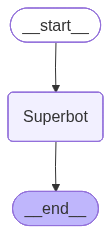

In [31]:
graph=StateGraph(State)

graph.add_node("Superbot",superbot)

graph.add_edge(START,"Superbot")
graph.add_edge("Superbot",END)

graph_builder=graph.compile()

from IPython.display import display,Image
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [32]:
## Invoke
graph_builder.invoke({'messages':"HI, I am divyansh"})

{'messages': [HumanMessage(content='HI, I am divyansh', additional_kwargs={}, response_metadata={}, id='c35d24f0-923a-4b44-96aa-5607106b6fa7'),
  AIMessage(content='Hello Divyansh! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 12, 'prompt_tokens': 14, 'total_tokens': 26, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_65564d8ba5', 'id': 'chatcmpl-CWoH72LCwBgnKayuilSbvh6lsBzlK', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--c45f0e44-1207-4c35-be93-33457775ce55-0', usage_metadata={'input_tokens': 14, 'output_tokens': 12, 'total_tokens': 26, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 're

In [33]:
### Streaming the responses
for event in graph_builder.stream({"messages":"hi i am divyansh"},stream_mode='values'):
    print(event)

{'messages': [HumanMessage(content='hi i am divyansh', additional_kwargs={}, response_metadata={}, id='a35c4652-5908-4880-8b16-89adc9cc45ec')]}
{'messages': [HumanMessage(content='hi i am divyansh', additional_kwargs={}, response_metadata={}, id='a35c4652-5908-4880-8b16-89adc9cc45ec'), AIMessage(content='Hello Divyansh! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 12, 'prompt_tokens': 13, 'total_tokens': 25, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_65564d8ba5', 'id': 'chatcmpl-CWoHDNpc1gK0ouKpnKyrXhRrgIQSb', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--c3c2117e-5019-4da5-b445-e2cea2c3c42d-0', usage_metadata={'input_tokens'